# Introduction to WaPOR and data loading

* **Products used:** 
[s2_l2a](https://explorer.digitalearth.africa/s2_l2a), 
[crop_mask](https://explorer.digitalearth.africa/crop_mask)

## Background
The **Wa**ter **P**roductivity through **O**pen access of **R**emotely sensed derived data (WaPOR) monitors and reports on agricultural water productivity through biophysical measures with a focus on Africa and the Near East. This information assists partner countries improve land and water productivity in both rainfed and irrigated agriculture ([Peiser et al. 2017](https://openknowledge.fao.org/items/cdacf817-c13a-4859-b681-a4bdc20c065c)). 

WaPOR provides numerous datasets related to vegetation productivity and water consumption, and associated meteorological and physical conditions such as soil moisture and precipitation. These datasets can be combined with Digital Earth Africa products, services, and workflows for numerous applications including:
   * Monitoring the water use efficiency of crops
   * Mapping irrigated areas
   * Estimating crop water requirements
   * Irrigation scheduling and budgeting

## Description
This notebook provides and introduction to WaPOR data and nomenclature, and demonstrates loading and plotting.

1. First, we explore the datasets available and how they are labelled.
2. Then, we download and plot annual data.
3. Finally, we download and plot dekadal (10 day temporal frequency) data.

***

## Getting started

To run this analysis, run all the cells in the notebook, starting with the "Load packages" cell. 

### Load packages
Import Python packages that are used for the analysis.

Use standard import commands; some are shown below. 
Begin with any `iPython` magic commands, followed by standard Python packages, then any additional functionality you need from the `Tools` package.

In [1]:
#!pip install wapordl

In [2]:
#!pip uninstall Tools -y
#!pip install ../../Tools

In [3]:
import datetime

import datacube
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rioxarray
import xarray as xr
from datacube.utils.masking import mask_invalid_data
from deafrica_tools.bandindices import calculate_indices
from deafrica_tools.datahandling import load_ard
from deafrica_tools.load_wapor import get_all_WaPORv3_mapsets, get_WaPORv3_info, load_wapor_ds
from deafrica_tools.plotting import display_map
from odc.algo import xr_reproject
from wapordl import wapor_map

### Connect to the datacube

Connect to the datacube so we can access DE Africa data.
The `app` parameter is a unique name for the analysis which is based on the notebook file name.

In [4]:
dc = datacube.Datacube(app="WaPOR")

### WaPOR Data

WaPOR data has three levels:
1. Global 300m resolution
2. National 100m resolution
3. Sub-national 20m resolution

The table below covers L1 and L2 datasets. L3 datasets can be viewed in the [WaPOR maps platform](https://data.apps.fao.org/wapor) which is built with the same software as [Digital Earth Africa Maps](https://maps.digitalearth.africa/). L3 datasets cover several regions of interest in northern and eastern Africa. This notebook loads level 3 20m data for Egypt. It is recommended that the [WaPOR maps platform](https://data.apps.fao.org/wapor) is inspected to check the availability of level, variable, and temporal frequency combinations for your area of interest. The maps platform also shows map codes in the data description.

Mapset codes are structured as `level-variable-temporal frequency` as shown below. The temporal frequencies available are:
* A - annual
* M - monthly
* D - dekadal (10 days)

So, for level 3 net primary productivity at dekadal intervals the code would be `L3-NPP-D`.

In [5]:
get_all_WaPORv3_mapsets()

,Mapset Code,Mapset Description
0,L1-AETI-A,Actual EvapoTranspiration and Interception (Gl...
1,L1-AETI-D,Actual EvapoTranspiration and Interception (Gl...
2,L1-AETI-M,Actual EvapoTranspiration and Interception (Gl...
3,L1-E-A,Evaporation (Global - Annual - 300m)
4,L1-E-D,Evaporation (Global - Dekadal - 300m)
5,L1-GBWP-A,Gross biomass water productivity (Annual - 300m)
6,L1-I-A,Interception (Global - Annual - 300m)
7,L1-I-D,Interception (Global - Dekadal - 300m)
8,L1-NBWP-A,Net biomass water productivity (Annual - 300m)
9,L1-NPP-D,Net Primary Production (Global - Dekadal - 300m)


### Analysis parameters

The cell below specifies:
* The area of interest. This can also be a `.geojson` file
* The folder where the downloaded data will be stored. If you are using this script repeatedly, it is recommended you empty this folder from time to time to manage storage. It is advised that any data required for repeated or future analysis is stored outside the sandbox.
* The variable of interest in the form of a mapset code, explained above.
* The period of interest.

In [6]:
region =  [31.30, 30.70, 31.40, 30.80] #xmin, ymin, xmax, ymax
folder = "Supplementary_data/WaPOR" # folder that the data will be sent to
variable = "L3-AETI-A" # level-variable-time, see table above
period = ["2018-01-01", "2024-02-01"] # period to load

This demonstration notebook loads an area of cropland in the Nile Delta, Egypt.

In [7]:
display_map(x=(region[0], region[2]), y=(region[1], region[3]))

### Download netCDF files

This cell downloads the data specified. The `aeti` object is the file path to the stored netCDF.

In [8]:
aeti = wapor_map(region, variable, period, folder, extension = '.nc')

INFO: Given `region` matches with `ENO` L3 region.
INFO: Found 6 files for L3-AETI-A.
INFO: Converting from `.tif` to `.nc`.


### Convert data to xarray

Below, the netCDFs are brought into the analysis environment as xarray datasets and coordinate labels and attributes are assigned.

In [9]:
aeti_xr = load_wapor_ds(filename=aeti, variable=variable)

### Inspect the xarray dataset

Now we have x, y, and time as dimensions and our variable (in this case, actual evapotranspiration and interception) as an xarray dataset. This enables us to easily deal with time and space for analysis.

In [10]:
aeti_xr

<xarray.Dataset>
Dimensions:      (x: 488, y: 548, time: 6)
Coordinates:
  * x            (x) float64 3.372e+05 3.372e+05 ... 3.469e+05 3.469e+05
  * y            (y) float64 3.409e+06 3.409e+06 ... 3.398e+06 3.398e+06
    spatial_ref  int32 32636
  * time         (time) datetime64[ns] 2018-01-01 2019-01-01 ... 2023-01-01
Data variables:
    L3-AETI-A    (time, y, x) int32 13087 12120 12641 ... 12388 12103 12062
Attributes:
    long_name:            Actual EvapoTranspiration and Interception
    overview:             NONE
    scale_factor:         0.1
    temporal_resolution:  Year
    units:                mm/year
    _FillValue:           -9999
    add_offset:           0.0

### Plot annual ET

The plots show how AETI varies in space and between years. In the Egypt example, the cropland areas are easily visible as areas with higher AETI.

Note that the scalebar is labelled with information from the WaPOR metadata. This can be accessed by calling `aeti_xr[variable].attrs`, as below, which can be especially useful when checking units for calculation.

In [11]:
aeti_xr[variable].attrs

{'long_name': 'Actual EvapoTranspiration and Interception',
 'overview': 'NONE',
 'scale_factor': 0.1,
 'temporal_resolution': 'Year',
 'units': 'mm/year',
 '_FillValue': -9999,
 'add_offset': 0.0}

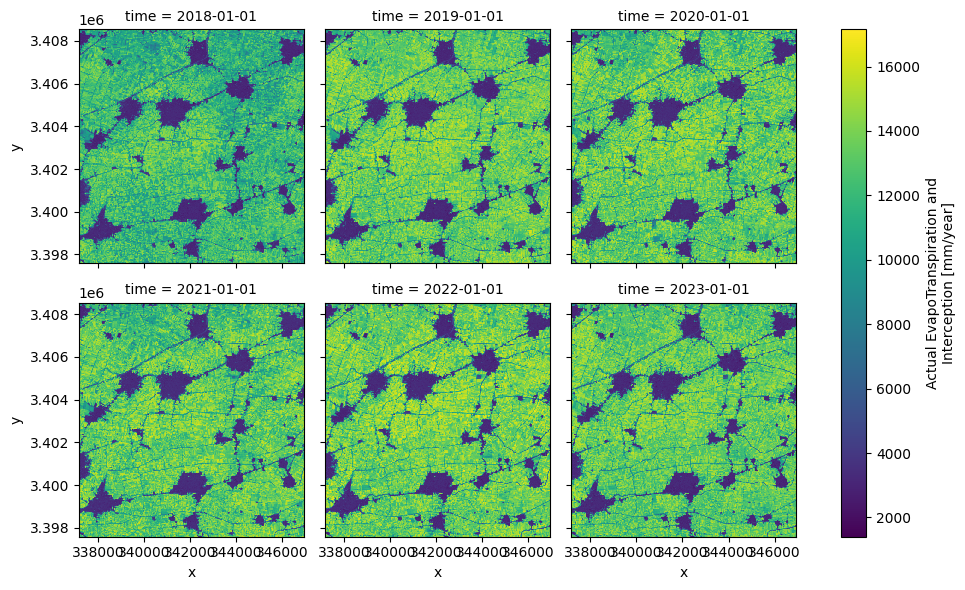

In [12]:
aeti_xr[variable].plot(col='time', col_wrap=3)

## Load annual biomass production

The cell below loads annual biomass production using the same procedure as for AETI. The only parameter changed is `variable`.

In [13]:
variable = 'L3-TBP-A' # change to total biomass production (TBP) mapset code

tbp = wapor_map(region, variable, period, folder, extension = '.nc')

tbp_xr = load_wapor_ds(filename=tbp, variable=variable)

tbp_xr

INFO: Given `region` matches with `ENO` L3 region.
INFO: Found 6 files for L3-TBP-A.
INFO: Converting from `.tif` to `.nc`.


<xarray.Dataset>
Dimensions:      (x: 488, y: 548, time: 6)
Coordinates:
  * x            (x) float64 3.372e+05 3.372e+05 ... 3.469e+05 3.469e+05
  * y            (y) float64 3.409e+06 3.409e+06 ... 3.398e+06 3.398e+06
    spatial_ref  int32 32636
  * time         (time) datetime64[ns] 2018-01-01 2019-01-01 ... 2023-01-01
Data variables:
    L3-TBP-A     (time, y, x) int32 23593 19816 20477 ... 24149 23679 23775
Attributes:
    long_name:            Total Biomass Production
    overview:             NONE
    temporal_resolution:  Year
    units:                kg/ha
    _FillValue:           -9999
    scale_factor:         1.0
    add_offset:           0.0

### Plot annual biomass production

It's interesting to note that in the Egypt example, some areas show very high biomass production > 30t/ha, especially in 2023. This must be considered in the context of several crop cycles occurring within a 12 month period.

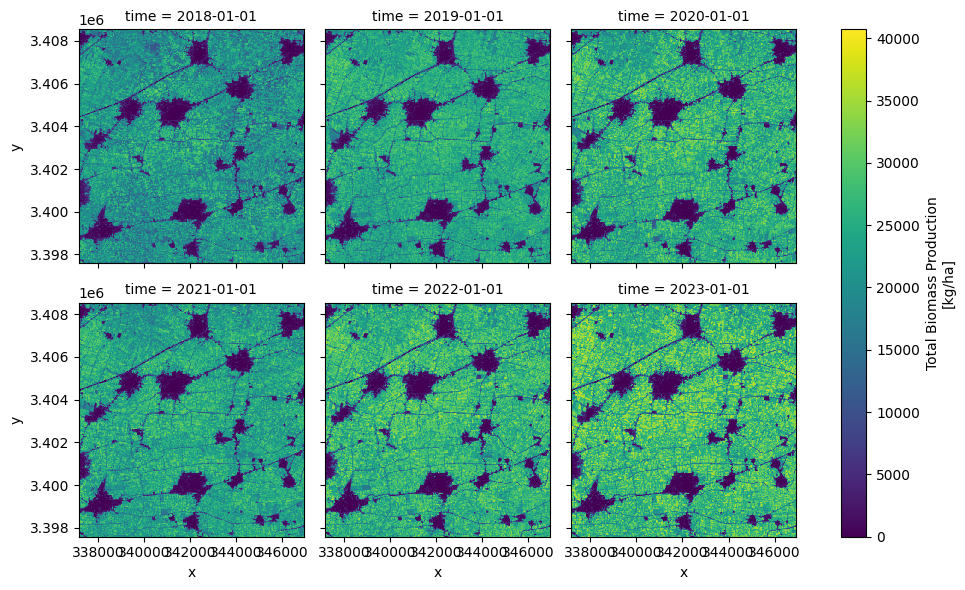

In [14]:
tbp_xr[variable].plot(col='time', col_wrap=3)

## Inspect phenology

In [15]:
period = ["2023-01-01", "2023-12-31"]

query = {
    "y": (region[1],region[3]),
    "x": (region[0],region[2]),
    "time": period,
    "measurements": ["red", "green", "blue", "nir"],
    "resolution": (-20, 20),
    "output_crs": "epsg:6933", #match wapor
    "group_by": "solar_day",
}

# Load available data from Sentinel-2
ds = load_ard(
    dc=dc,
    products=["s2_l2a"],
    **query,
)

ds

Using pixel quality parameters for Sentinel 2
Finding datasets
    s2_l2a
Applying pixel quality/cloud mask
Loading 75 time steps


/usr/local/lib/python3.10/dist-packages/rasterio/warp.py:344: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  _reproject(


<xarray.Dataset>
Dimensions:      (time: 75, y: 551, x: 483)
Coordinates:
  * time         (time) datetime64[ns] 2023-01-03T08:41:37 ... 2023-12-29T08:...
  * y            (y) float64 3.747e+06 3.747e+06 ... 3.736e+06 3.736e+06
  * x            (x) float64 3.02e+06 3.02e+06 3.02e+06 ... 3.03e+06 3.03e+06
    spatial_ref  int32 6933
Data variables:
    red          (time, y, x) float32 nan nan nan nan ... 392.0 363.0 490.0
    green        (time, y, x) float32 nan nan nan nan ... 583.0 682.0 714.0
    blue         (time, y, x) float32 nan nan nan nan ... 287.0 282.0 340.0
    nir          (time, y, x) float32 nan nan nan ... 4.244e+03 4.277e+03
Attributes:
    crs:           epsg:6933
    grid_mapping:  spatial_ref

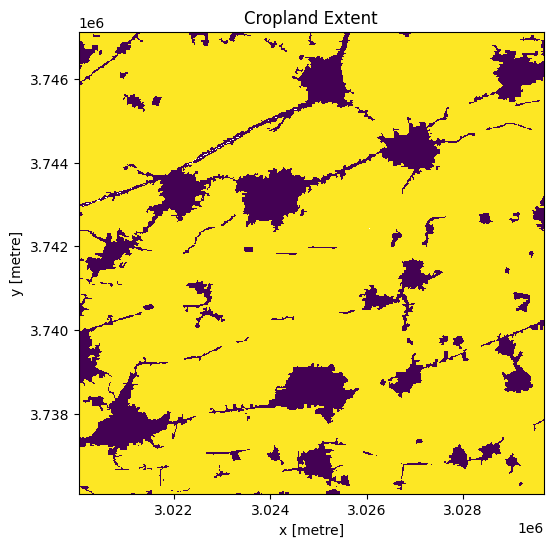

In [16]:
cm = dc.load(
    product="crop_mask",
    time=("2019"),
    measurements="filtered",
    resampling="nearest",
    like=ds.geobox,
).filtered.squeeze()

cm.where(cm < 255).plot.imshow(
    add_colorbar=False, figsize=(6, 6)
)  # we filter to <255 to omit missing data
plt.title("Cropland Extent");

In [17]:
ds = ds.where(cm == 1)

In [18]:
ds = calculate_indices(ds, index='EVI', satellite_mission="s2")

In [19]:
resample_period = "10D"
window = 4

veg_smooth = (
    ds['EVI']
    .resample(time=resample_period)
    .median()
    .rolling(time=window, min_periods=1)
    .mean()
)

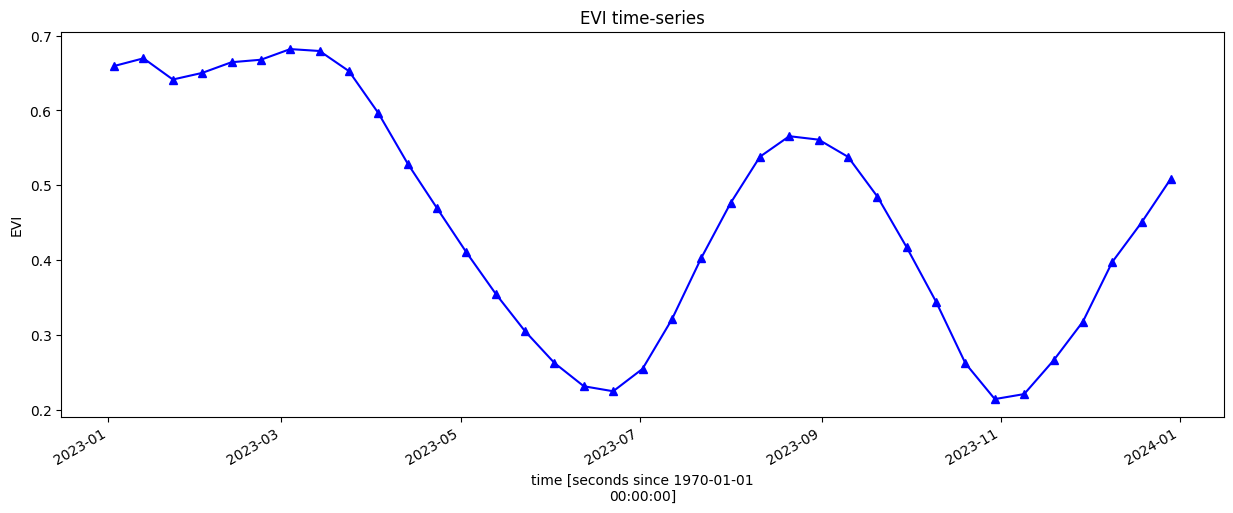

In [20]:
veg_smooth_1D = veg_smooth.mean(["x", "y"])
veg_smooth_1D.plot.line("b-^", figsize=(15, 5))
_max = veg_smooth_1D.max()
_min = veg_smooth_1D.min()

plt.title("EVI time-series")
plt.ylabel('EVI');

## Load dekadal evapotranspiration

In [21]:
period = ['2023-06-20', '2023-11-01']
variable = 'L3-AETI-D'

aetid = wapor_map(region, variable, period, folder, extension = '.nc')

aetid_xr = load_wapor_ds(filename=aetid, variable=variable)

aetid_xr

INFO: Given `region` matches with `ENO` L3 region.
INFO: Found 15 files for L3-AETI-D.
INFO: Converting from `.tif` to `.nc`.


<xarray.Dataset>
Dimensions:      (x: 488, y: 548, time: 15)
Coordinates:
  * x            (x) float64 3.372e+05 3.372e+05 ... 3.469e+05 3.469e+05
  * y            (y) float64 3.409e+06 3.409e+06 ... 3.398e+06 3.398e+06
    spatial_ref  int32 32636
  * time         (time) datetime64[ns] 2023-06-11 2023-06-21 ... 2023-11-01
Data variables:
    L3-AETI-D    (time, y, x) int16 36 34 36 34 35 38 33 ... 14 14 15 13 10 9 10
Attributes:
    long_name:            Actual EvapoTranspiration and Interception
    overview:             NONE
    scale_factor:         0.1
    temporal_resolution:  Dekad
    units:                mm/day
    _FillValue:           -9999
    add_offset:           0.0

In [22]:
# Reproject data
aetid_xr_reprojected = aetid_xr.odc.reproject(how=ds.odc.geobox, resampling="average")

#Set nodata to `NaN`
aetid_xr_reprojected = mask_invalid_data(aetid_xr_reprojected)
aetid_xr_reprojected

<xarray.Dataset>
Dimensions:      (time: 15, y: 551, x: 483)
Coordinates:
    spatial_ref  int32 6933
  * time         (time) datetime64[ns] 2023-06-11 2023-06-21 ... 2023-11-01
  * y            (y) float64 3.747e+06 3.747e+06 ... 3.736e+06 3.736e+06
  * x            (x) float64 3.02e+06 3.02e+06 3.02e+06 ... 3.03e+06 3.03e+06
Data variables:
    L3-AETI-D    (time, y, x) float32 nan nan nan nan nan ... nan nan nan nan

In [23]:
aetid_xr_crop = aetid_xr_reprojected.where(cm == 1)

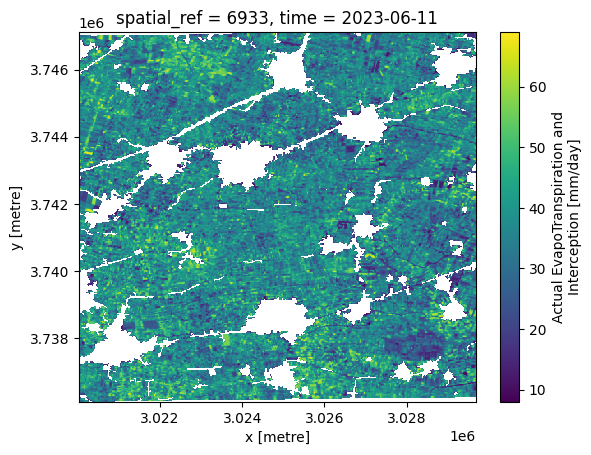

In [24]:
aetid_xr_crop['L3-AETI-D'].isel(time=0).plot()

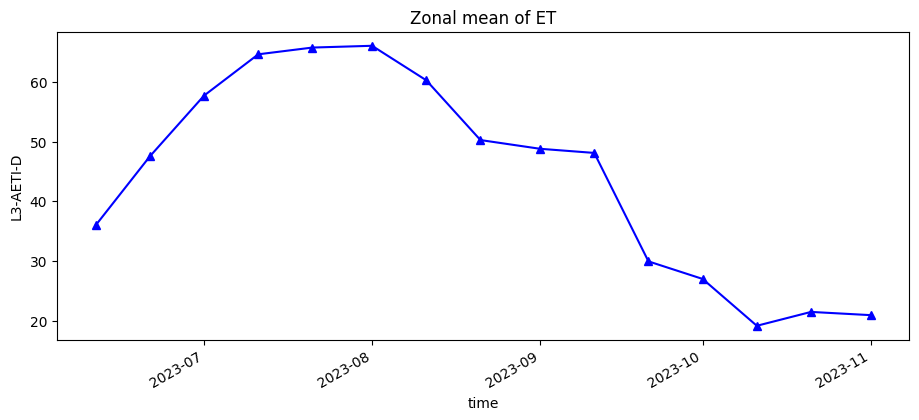

In [25]:
aetid_xr_crop['L3-AETI-D'].mean(["x", "y"]).plot.line("b-^", figsize=(11, 4))
plt.title("Zonal mean of ET");

## Load dekadal Net Primary Productivity

In [26]:
variable = 'L3-NPP-D'

nppd = wapor_map(region, variable, period, folder, extension = '.nc')

nppd_xr = load_wapor_ds(filename=nppd, variable=variable)

# Reproject data
nppd_xr_reprojected = xr_reproject(src=nppd_xr,
                              geobox=ds.geobox,
                              resampling="average")

#Set nodata to `NaN`
nppd_xr_reprojected = mask_invalid_data(nppd_xr_reprojected)

nppd_xr_crop = nppd_xr_reprojected.where(cm == 1)

nppd_xr_crop

INFO: Given `region` matches with `ENO` L3 region.
INFO: Found 15 files for L3-NPP-D.
INFO: Converting from `.tif` to `.nc`.


<xarray.Dataset>
Dimensions:      (time: 15, y: 551, x: 483)
Coordinates:
  * y            (y) float64 3.747e+06 3.747e+06 ... 3.736e+06 3.736e+06
  * x            (x) float64 3.02e+06 3.02e+06 3.02e+06 ... 3.03e+06 3.03e+06
    spatial_ref  int32 6933
  * time         (time) datetime64[ns] 2023-06-11 2023-06-21 ... 2023-11-01
Data variables:
    L3-NPP-D     (time, y, x) float32 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0

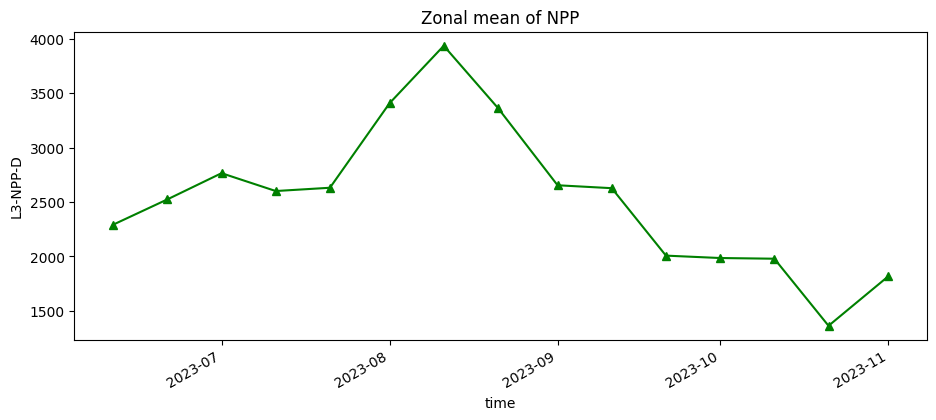

In [27]:
nppd_xr_crop['L3-NPP-D'].mean(["x", "y"]).plot.line("g-^", figsize=(11, 4))
plt.title("Zonal mean of NPP");

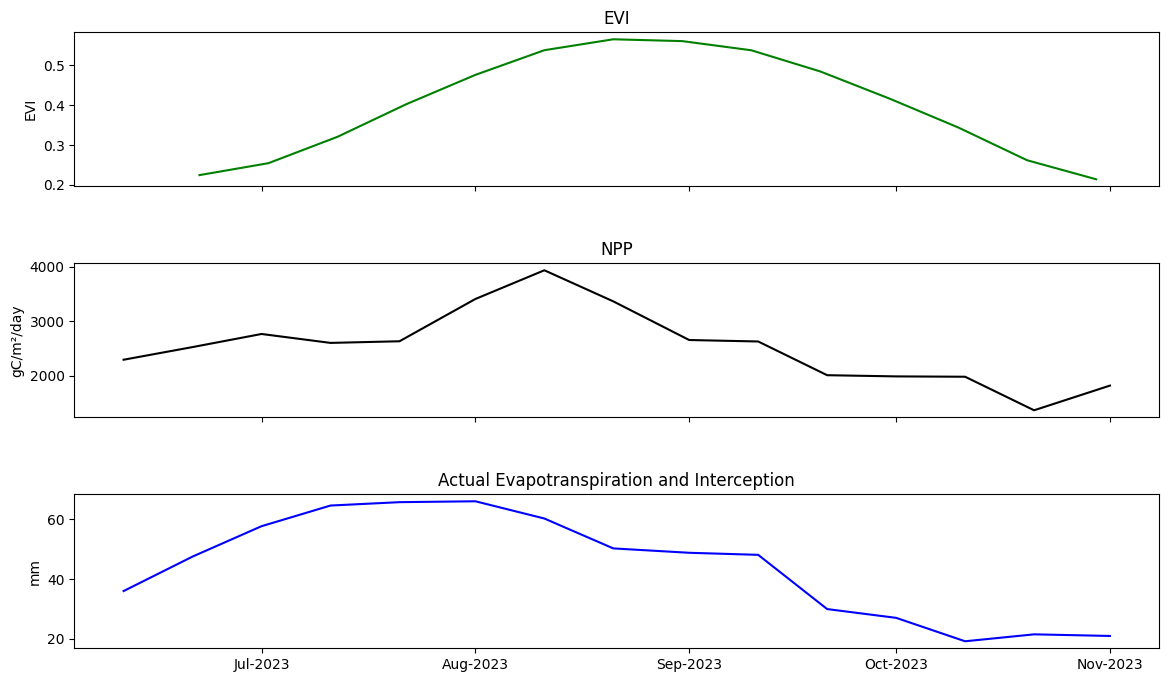

In [28]:
fig, axs = plt.subplots(3, sharex=True, figsize=(14,8), gridspec_kw={'hspace': 0.5})

veg_smooth_1D_slice = veg_smooth_1D.sel(time=slice(*period))

axs[0].set_title('EVI')
axs[0].set_ylabel('EVI')
axs[0].plot(veg_smooth_1D_slice.time, veg_smooth_1D_slice, color='green')

axs[1].set_title('NPP')
axs[1].set_ylabel('gC/m²/day')
axs[1].plot(nppd_xr_crop['L3-NPP-D'].mean(["x", "y"]).time, nppd_xr_crop['L3-NPP-D'].mean(["x", "y"]), color='black')

axs[2].set_title('Actual Evapotranspiration and Interception')
axs[2].set_ylabel('mm')
axs[2].plot(aetid_xr_crop['L3-AETI-D'].mean(["x", "y"]).time, aetid_xr_crop['L3-AETI-D'].mean(["x", "y"]), color='blue')
axs[2].xaxis_date()
axs[2].xaxis.set_major_formatter(mdates.DateFormatter("%b-%Y"))